# Integration of Excitatory neurons in Monkey AAI and Monkey V1

In [1]:
%pylab inline
import scanpy as sc
import pandas as pd
import seaborn as sns
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

rcParams['pdf.fonttype']=42 # in order to save fonttype in AI
rcParams['ps.fonttype']=42

import warnings
warnings.filterwarnings("ignore")

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


# load data...

In [2]:
# load the Insular data...
insData = sc.read('../data_h5/Ext.h5ad')

/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


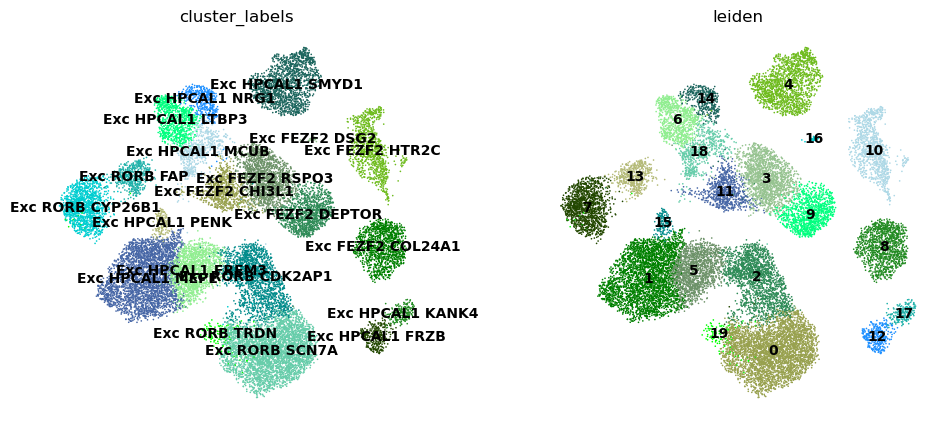

In [3]:
figsize(5,5)
sc.pl.umap(insData,color=['cluster_labels','leiden'],frameon='',legend_loc='on data' )

In [4]:
insData

AnnData object with n_obs × n_vars = 21733 × 19944
    obs: 'batch', 'doublet_score', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cluster_labels', 'sampleLayers', 'projectionCellType'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'batch_colors', 'cluster_labels_colors', 'cluster_names', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'projectionCellType_colors', 'rank_genes_groups', 'sampleLayers_colors', 'tsne', 'umap'
    obsm: 'X_harmonypca', 'X_pca', 'X_tsne', 'X_umap', 'X_umapharmony', 'X_umapraw'
    varm: 'PCs'
    layers: 'RawCounts'
    obsp: 'connectivities', 'distances'

In [5]:
ins_adata=insData.layers['RawCounts']
ins_adata.obs['batch'] = insData.obs['batch'].astype('str')
ins_adata.obs['brainArea'] = 'Ins'
ins_adata.obs['species'] = 'monkey_Ins'
ins_adata.obs['cellTypeID'] = insData.obs['leiden']
ins_adata.obs['cellTypeLabel'] = insData.obs['cluster_labels']
ins_adata.obs['pct_counts_mt'] = insData.obs['pct_counts_mt']

del(insData)

In [6]:
# load the human counts data...
adata_v1 = sc.read('./data_V1/FM27_cell_133454_wk_1_backup.h5')

In [7]:
adata_v1

AnnData object with n_obs × n_vars = 133454 × 18297
    obs: 'Layer', 'MonkeyID', 'age', 'batch', 'cell_label', 'cell_label_old', 'class', 'louvain', 'marker1', 'marker2', 'n_counts', 'n_genes', 'name', 'percent_mito', 'subclass', 'cell_label_reorder', 'class_new', 'predict_type', 'class_show', 'cell_label1', 'cell_label_20210903', 'sex', 'subclass_1', 'cell_label_dendro', 'subclass_2'
    var: 'ENS', 'x', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Layer_colors', 'MonkeyID_colors', 'age_colors', 'cell_label1_colors', 'cell_label_colors', 'cell_label_colors_old', 'cell_label_colors_purpleNXPH4', 'cell_label_dendro_colors', 'cell_label_old_colors', 'cell_label_reorder_colors', 'class_colors', 'class_show_colors', 'dendrogram_cell_label_dendro', 'marker1_colors', 'marker2_colors', 'sex_colors', 'subclass_1_colors', 'subclass_2_colors', 'subclass_colors', 'sublcass_1_colors'
    obsm: 'X_harmonypca', 'X_neuron_tsne', 'X_pca', 'X_tsne',

In [8]:
# select the inhibitory neurons
adata_v1 = adata_v1[adata_v1.obs['batch'].isin(['0'])]

# create new scanpy object.
v1_adata=sc.AnnData(adata_v1.layers['counts'],dict(obs_names=adata_v1.obs_names),dict(var_names=adata_v1.var_names))
v1_adata.obs['species'] = 'monkey_V1'

v1_adata.obs['batch'] = adata_v1.obs['name']
v1_adata.obs['brainArea'] = 'V1'
v1_adata.obs['pct_counts_mt'] = adata_v1.obs['percent_mito']

# sex_str = adata_v1.obs['sex'].astype(str)
# sex_str[ adata_v1.obs['sex']=='M'] = 'Male'
# sex_str[  adata_v1.obs['sex']=='F' ] = 'Female'
# v1_adata.obs['Sex'] = adata_v1.obs['sex']

v1_adata.obs['cell_label1'] = adata_v1.obs['cell_label1']
v1_adata.obs['subclass_1'] = adata_v1.obs['subclass_1']
v1_adata.obs['subclass_2'] = adata_v1.obs['subclass_2']
v1_adata.uns['subclass_1_colors'] = adata_v1.uns['subclass_1_colors']
v1_adata.uns['cell_label1_colors'] = adata_v1.uns['cell_label1_colors']

del(adata_v1)

In [9]:
ins_adata

AnnData object with n_obs × n_vars = 21733 × 19944
    obs: 'batch', 'doublet_score', 'predicted_doublets', 'brainArea', 'species', 'cellTypeID', 'cellTypeLabel', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types'

In [10]:
ins_adata.obs['batch_ori']=ins_adata.obs['batch']
v1_adata.obs['batch_ori']=v1_adata.obs['batch']

# integrate the datasets and compare the clusters...

In [12]:
adata = ins_adata.concatenate(v1_adata,index_unique = None)

/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/anndata/_core/anndata.py:1785: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  [AnnData(sparse.csr_matrix(a.shape), obs=a.obs) for a in all_adatas],
/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/anndata/_core/anndata.py:1785: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  [AnnData(sparse.csr_matrix(a.shape), obs=a.obs) for a in all_adatas],


In [13]:
adata

AnnData object with n_obs × n_vars = 69493 × 18268
    obs: 'batch', 'doublet_score', 'predicted_doublets', 'brainArea', 'species', 'cellTypeID', 'cellTypeLabel', 'pct_counts_mt', 'batch_ori', 'cell_label1', 'subclass_1', 'subclass_2'
    var: 'gene_ids-0', 'feature_types-0'

In [14]:
adata.layers['RawCounts']=adata.X

In [15]:
del(adata.obs['predicted_doublets'])

In [16]:
adata.var['mt'] = adata.var_names.isin(["ND1","ND2","COX1","COX2","COX3","ATP6","ATP8","ND3","ND4","ND5","ND6","ND4L","CYTB"])

In [17]:
adata.write('./data_tem/tem_integrated_Exc_ins_vs_v1_1_20250917.h5ad',compression='gzip')

In [ ]:
# adata = sc.read('./data_tem/tem_integrated_Exc_ins_vs_v1_1_20250917.h5ad')

In [18]:
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(
    adata,
    batch_key="batch",
    flavor="seurat",
    n_top_genes=500,
    subset=True,
    min_mean=0.015, 
    max_mean=10,
    min_disp=0.05
)

/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:478: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:478: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)


In [19]:
adata = adata[:, adata.var.highly_variable]
adata

View of AnnData object with n_obs × n_vars = 69493 × 500
    obs: 'batch', 'doublet_score', 'brainArea', 'species', 'cellTypeID', 'cellTypeLabel', 'pct_counts_mt', 'batch_ori', 'cell_label1', 'subclass_1', 'subclass_2', 'n_genes_by_counts', 'total_counts', 'n_counts'
    var: 'gene_ids-0', 'feature_types-0', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg'
    layers: 'RawCounts'

In [20]:
sc.pp.regress_out(adata, ['total_counts','pct_counts_mt'])
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)

/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


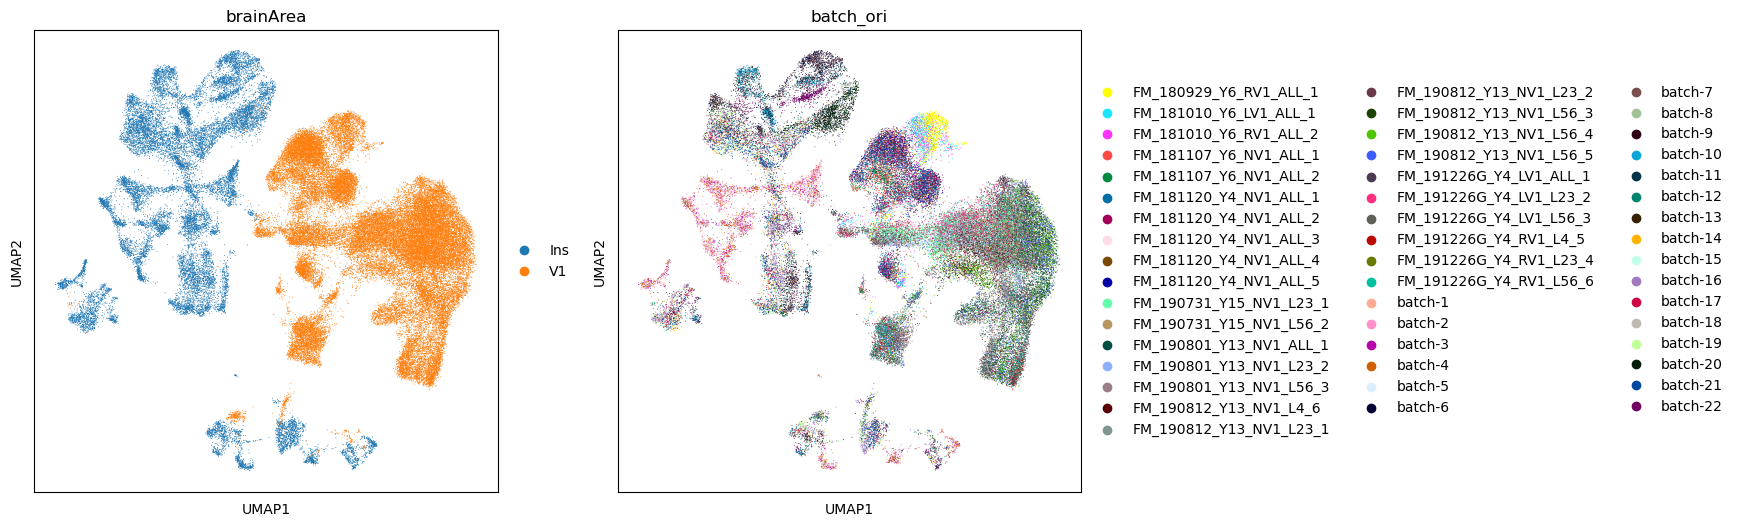

In [21]:
figsize(6,6)
sc.pl.umap(adata,color=['brainArea','batch_ori'])

In [22]:
adata.write('./data_tem/tem_integrated_Exc_ins_vs_v1_2_20250917.h5ad',compression='gzip')

## Integrate with harmoney

In [23]:
adata = sc.read('./data_tem/tem_integrated_Exc_ins_vs_v1_2_20250917.h5ad')

In [24]:
import harmonypy as hm
ho = hm.run_harmony(adata.obsm['X_pca'], adata.obs, ['batch_ori'],theta=8)
adata.obsm['X_harmonypca'] = ho.Z_corr.T
sc.pp.neighbors(adata, use_rep='X_harmonypca')
adata.obsm['X_umapraw'] = adata.obsm['X_umap']
sc.tl.umap(adata)
adata.obsm['X_umapharmony'] = adata.obsm['X_umap']

2025-09-17 14:20:48,167 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-09-17 14:21:08,182 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-09-17 14:21:08,461 - harmonypy - INFO - Iteration 1 of 10
2025-09-17 14:21:43,263 - harmonypy - INFO - Iteration 2 of 10
2025-09-17 14:22:17,719 - harmonypy - INFO - Iteration 3 of 10
2025-09-17 14:22:44,452 - harmonypy - INFO - Iteration 4 of 10
2025-09-17 14:23:12,664 - harmonypy - INFO - Iteration 5 of 10
2025-09-17 14:23:36,184 - harmonypy - INFO - Iteration 6 of 10
2025-09-17 14:23:53,402 - harmonypy - INFO - Iteration 7 of 10
2025-09-17 14:24:11,806 - harmonypy - INFO - Iteration 8 of 10
2025-09-17 14:24:26,914 - harmonypy - INFO - Iteration 9 of 10
2025-09-17 14:24:40,968 - harmonypy - INFO - Iteration 10 of 10
2025-09-17 14:24:59,531 - harmonypy - INFO - Stopped before convergence


In [25]:
adata

AnnData object with n_obs × n_vars = 69493 × 500
    obs: 'batch', 'doublet_score', 'brainArea', 'species', 'cellTypeID', 'cellTypeLabel', 'pct_counts_mt', 'batch_ori', 'cell_label1', 'subclass_1', 'subclass_2', 'n_genes_by_counts', 'total_counts', 'n_counts'
    var: 'gene_ids-0', 'feature_types-0', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'batch_ori_colors', 'brainArea_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'X_harmonypca', 'X_umapraw', 'X_umapharmony'
    varm: 'PCs'
    layers: 'RawCounts'
    obsp: 'connectivities', 'distances'

/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


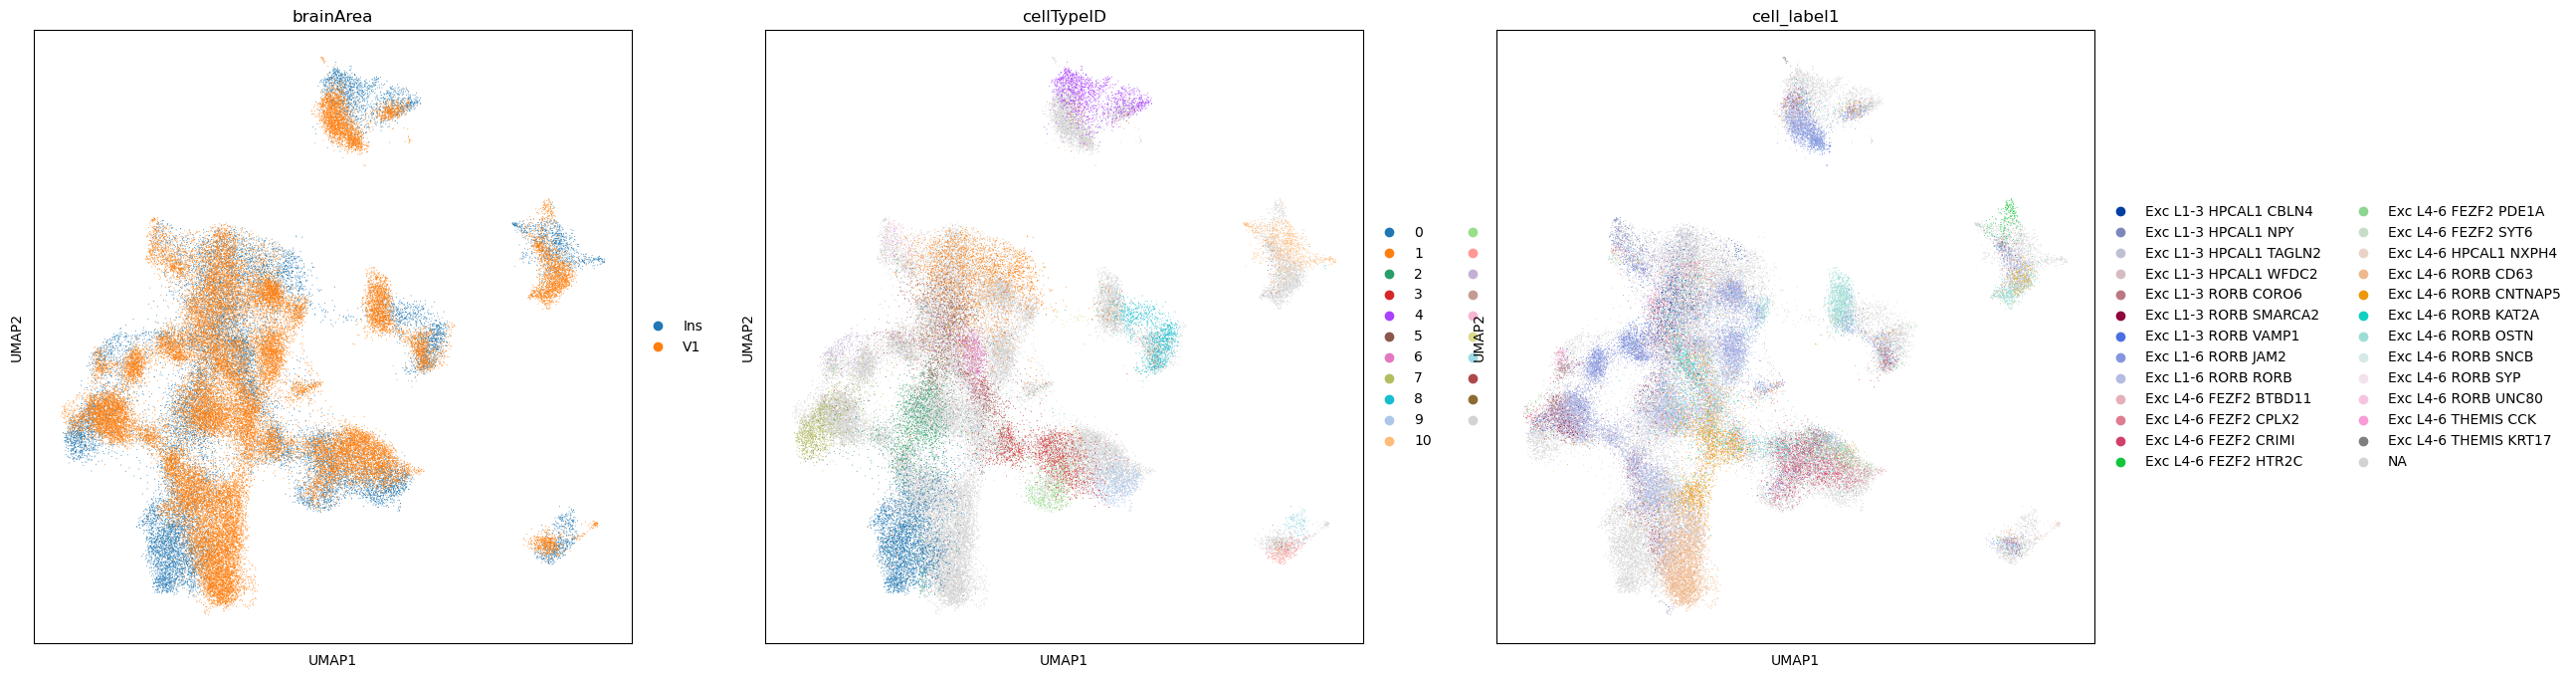

In [26]:
figsize(8,8)
sc.pl.umap(adata,color=['brainArea','cellTypeID','cell_label1'])

In [27]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
%pylab inline
import sys
sys.path.append('../tools')
from two_species_heatmap import *

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [ ]:
# sc.pp.neighbors(adata,  metric='euclidean',use_rep = 'X_harmonypca' )
# sc.tl.louvain(adata, resolution = 1.0, key_added = 'louvain')
# adata.obs['louvain1_0'] = adata.obs['louvain']

/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


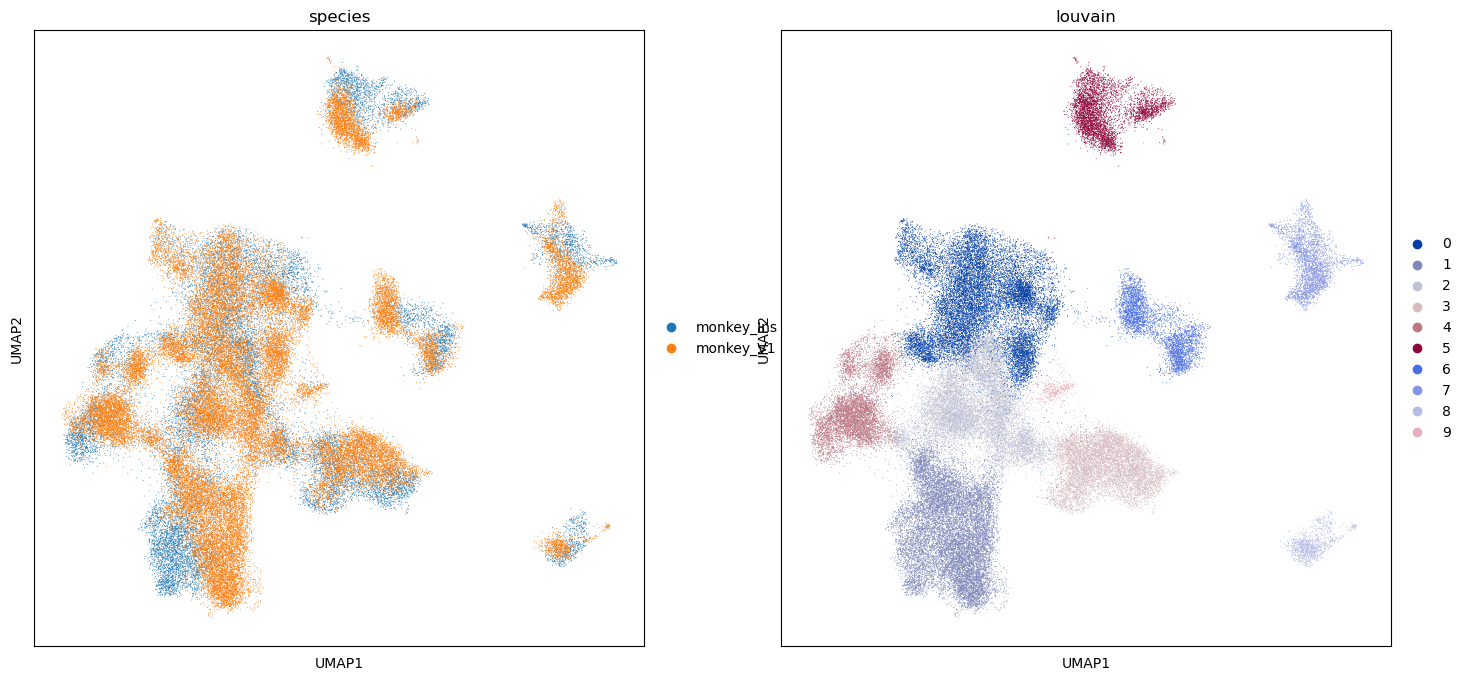

/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


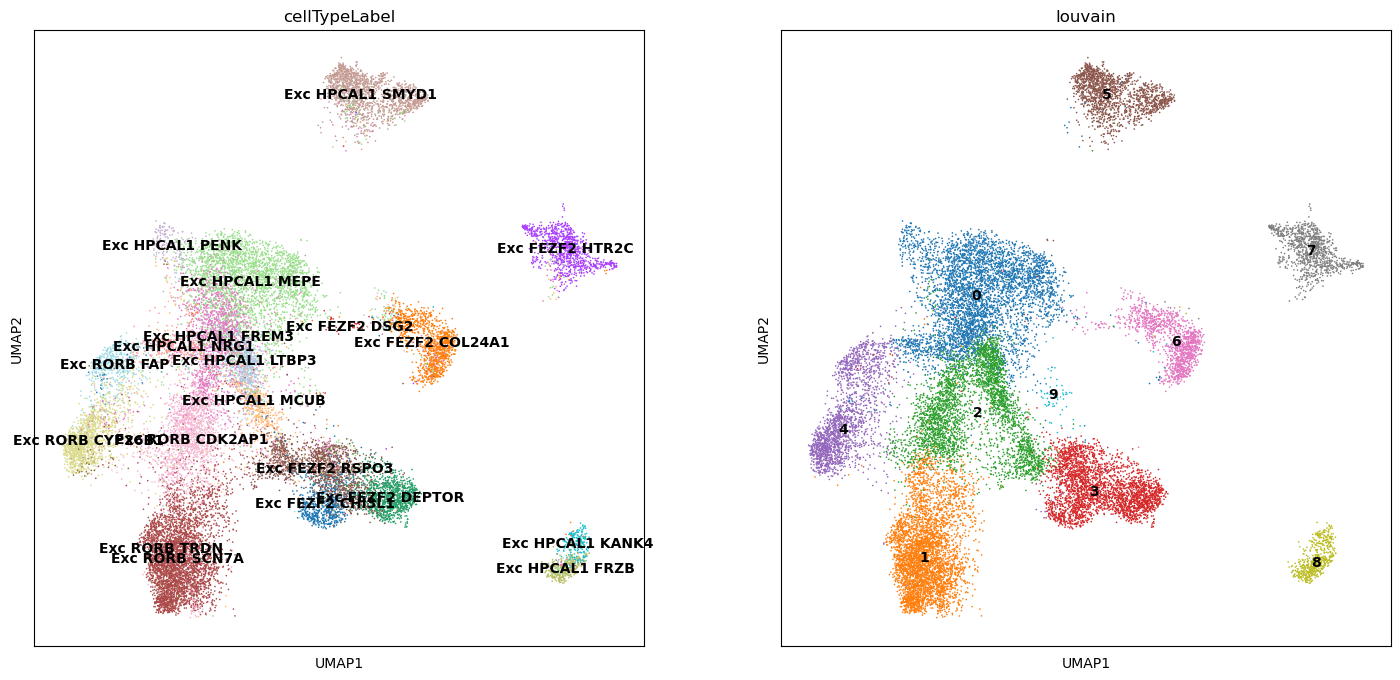

/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


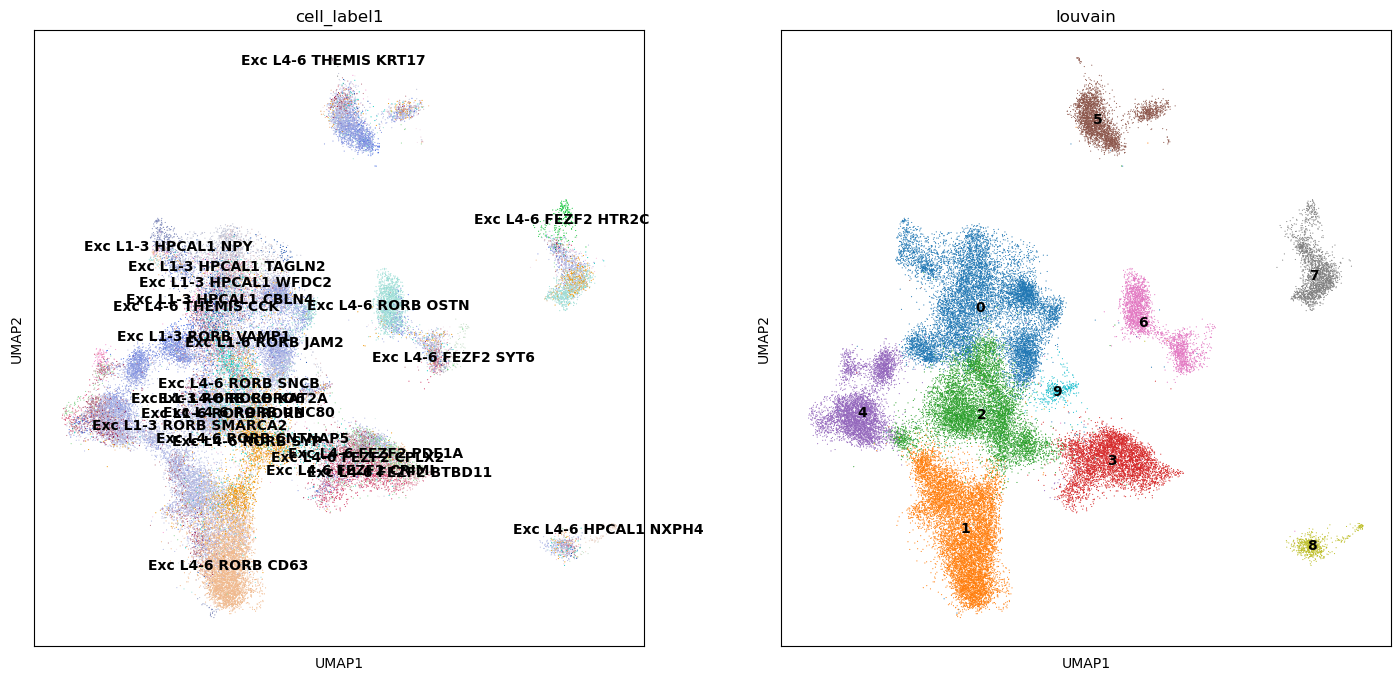

/mnt/e/workDocs/JupyterNotebook/InsPatchSeq/10X/Integrate_mk_ins_vs_mk_V1/../tools/two_species_heatmap.py:100: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  low_sum_matrix_sort2.loc['max_order',hu_cluster]= float(tmp.index(max(tmp)))


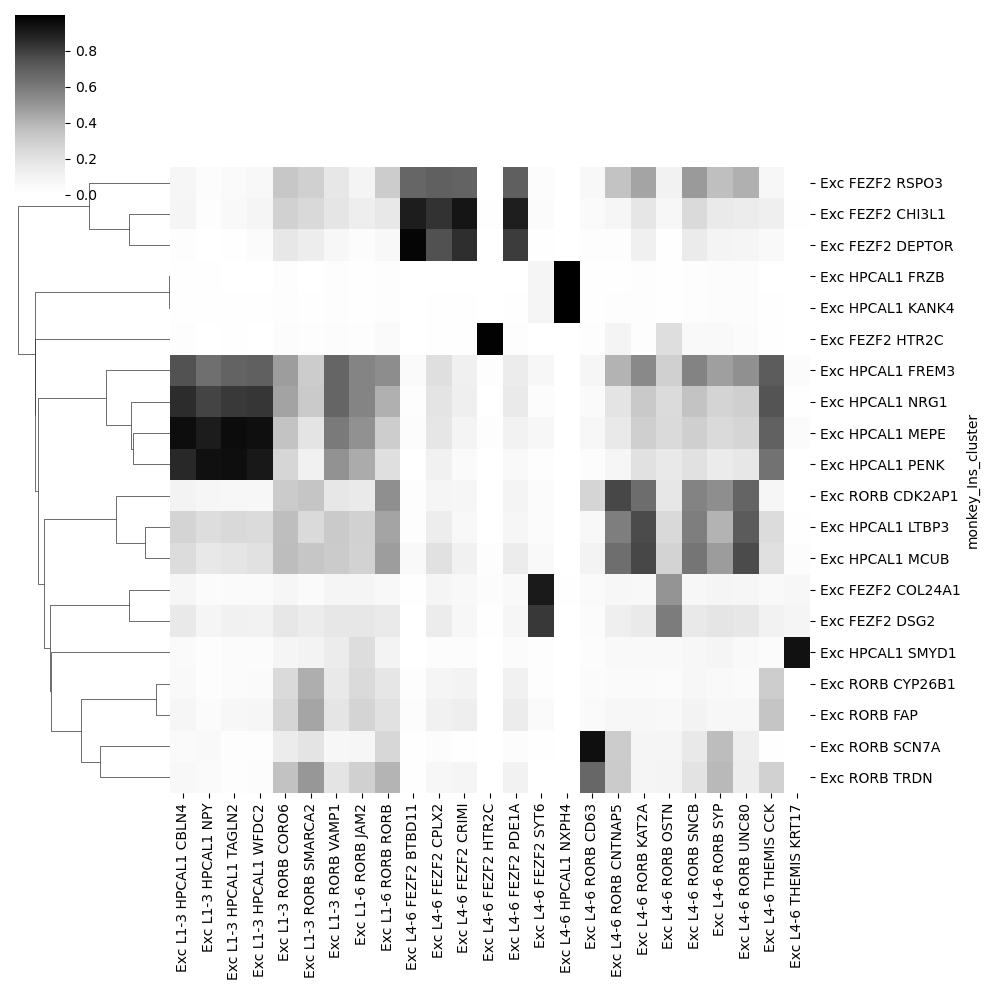

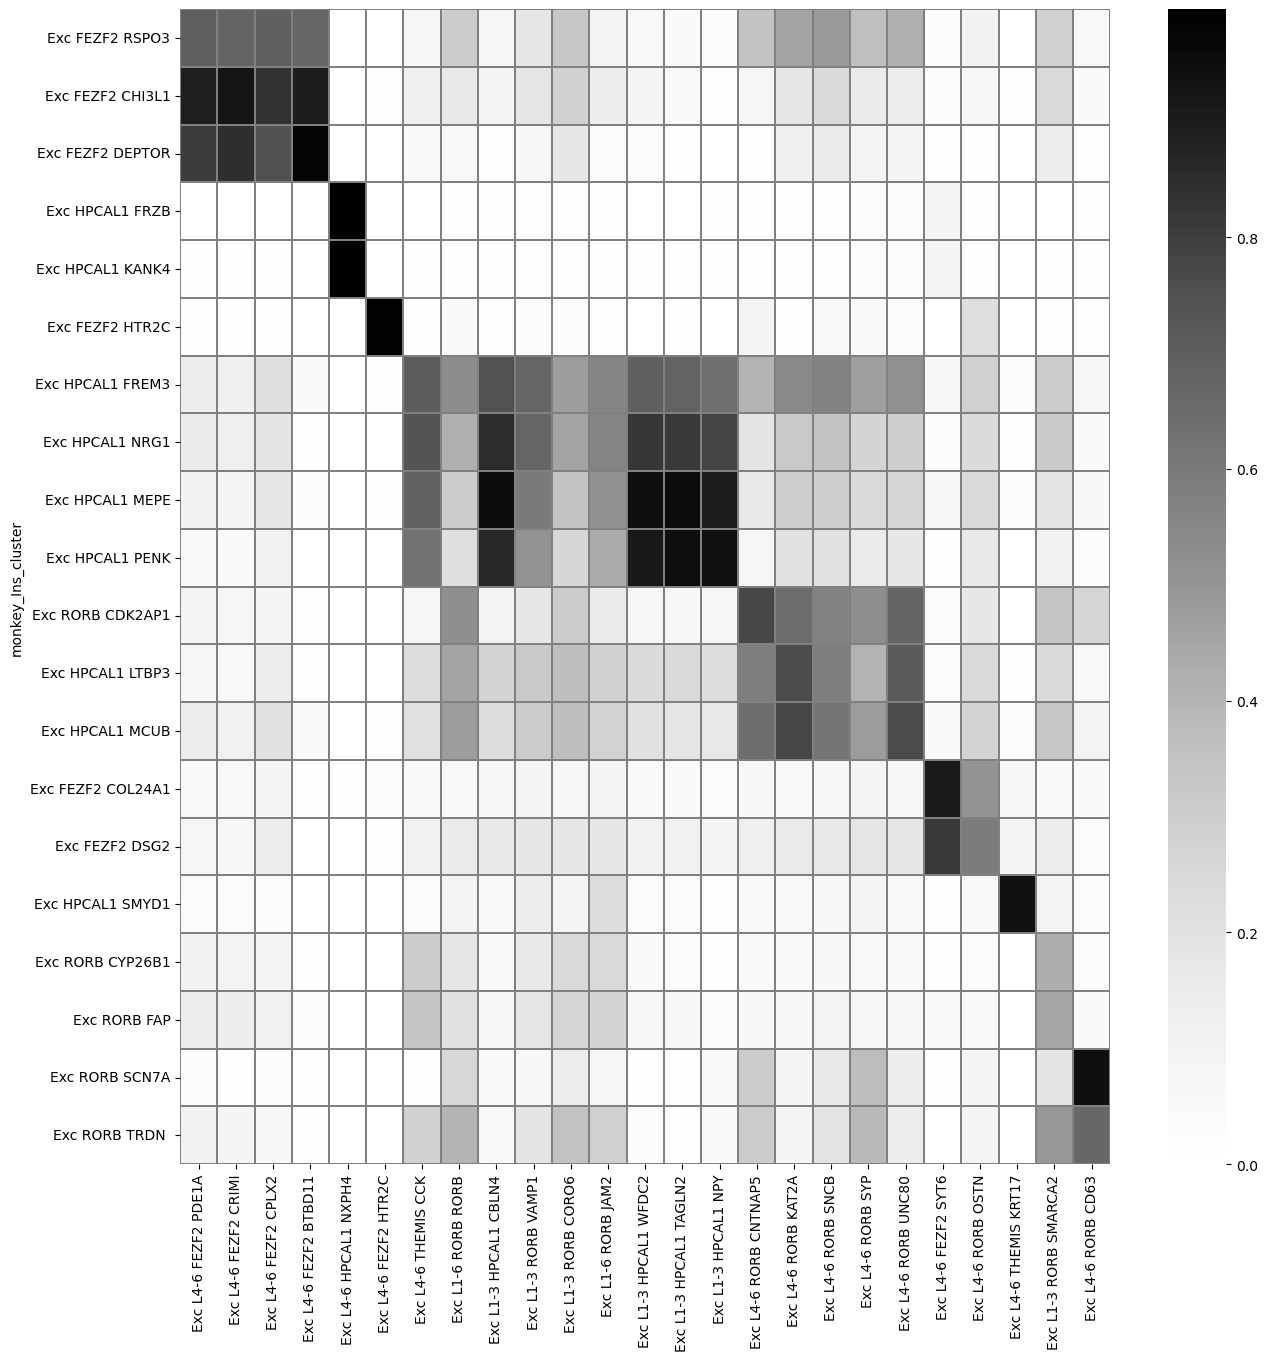

In [53]:
plot_NeuronMatrix_ins_vs_V1_lovain_0_5 = two_species_heatmap(adata, species_1 = 'monkey_Ins', species_2 = 'monkey_V1',\
                species_1_key = 'cellTypeLabel', species_2_key = 'cell_label1',\
                louvain = 0.5)#,figure_path = 'neurons_heatmap_cmp.png')

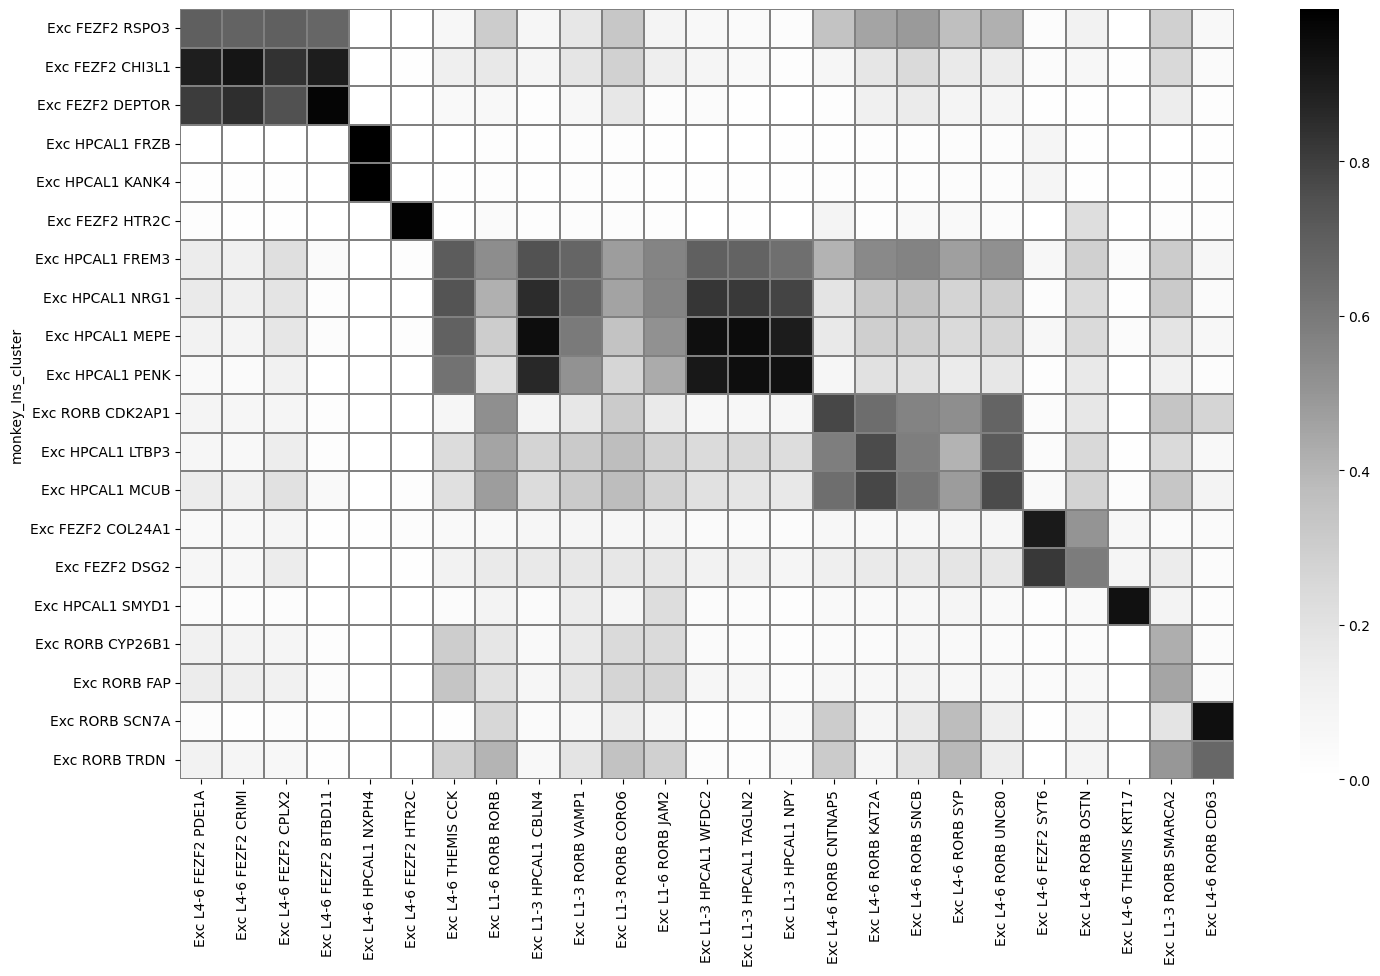

In [60]:
plt.figure(figsize = (17,10))
sns_plot = sns.heatmap(plot_NeuronMatrix_ins_vs_V1_lovain_0_5, cmap='Greys', cbar=True, xticklabels=1,yticklabels=1, linewidth = 0.01, linecolor = 'gray')
plt.savefig('figs/cmpMatrix_Exc_Ins_vs_V1_500VirableGenes_resolution_0_5.pdf',dpi = 600, )

In [50]:
plot_NeuronMatrix_ins_vs_V1_lovain_0_5.index

Index(['Exc HPCAL1 MEPE', 'Exc HPCAL1 PENK', 'Exc FEZF2 RSPO3',
       'Exc FEZF2 CHI3L1', 'Exc FEZF2 DEPTOR', 'Exc HPCAL1 FREM3',
       'Exc RORB CDK2AP1', 'Exc HPCAL1 MCUB', 'Exc HPCAL1 LTBP3',
       'Exc HPCAL1 NRG1', 'Exc HPCAL1 FRZB', 'Exc HPCAL1 KANK4',
       'Exc FEZF2 HTR2C', 'Exc FEZF2 COL24A1', 'Exc FEZF2 DSG2',
       'Exc HPCAL1 SMYD1', 'Exc RORB CYP26B1', 'Exc RORB FAP',
       'Exc RORB TRDN ', 'Exc RORB SCN7A'],
      dtype='object', name='monkey_Ins_cluster')

In [51]:
plot_NeuronMatrix_ins_vs_V1_lovain_0_5.columns

Index(['Exc L1-3 HPCAL1 CBLN4', 'Exc L1-3 HPCAL1 NPY',
       'Exc L1-3 HPCAL1 TAGLN2', 'Exc L1-3 HPCAL1 WFDC2',
       'Exc L4-6 THEMIS CCK', 'Exc L4-6 FEZF2 PDE1A', 'Exc L4-6 FEZF2 CRIMI',
       'Exc L4-6 FEZF2 CPLX2', 'Exc L4-6 FEZF2 BTBD11',
       'Exc L4-6 RORB CNTNAP5', 'Exc L1-6 RORB JAM2', 'Exc L1-3 RORB VAMP1',
       'Exc L4-6 RORB UNC80', 'Exc L1-3 RORB CORO6', 'Exc L4-6 RORB SYP',
       'Exc L4-6 RORB SNCB', 'Exc L1-6 RORB RORB', 'Exc L4-6 RORB KAT2A',
       'Exc L4-6 HPCAL1 NXPH4', 'Exc L4-6 FEZF2 HTR2C', 'Exc L4-6 FEZF2 SYT6',
       'Exc L4-6 RORB OSTN', 'Exc L4-6 THEMIS KRT17', 'Exc L1-3 RORB SMARCA2',
       'Exc L4-6 RORB CD63'],
      dtype='object')

In [55]:
# index_order = ['Exc HPCAL1 MEPE', 'Exc HPCAL1 PENK', 'Exc FEZF2 RSPO3',
#        'Exc FEZF2 CHI3L1', 'Exc FEZF2 DEPTOR', 'Exc HPCAL1 FREM3',
#        'Exc RORB CDK2AP1', 'Exc HPCAL1 MCUB', 'Exc HPCAL1 LTBP3',
#        'Exc HPCAL1 NRG1', 'Exc HPCAL1 FRZB', 'Exc HPCAL1 KANK4',
#        'Exc FEZF2 HTR2C', 'Exc FEZF2 COL24A1', 'Exc FEZF2 DSG2',
#        'Exc HPCAL1 SMYD1', 'Exc RORB CYP26B1', 'Exc RORB FAP',
#         'Exc RORB TRDN ', 'Exc RORB SCN7A',]

# column_order = ['Exc L1-3 HPCAL1 CBLN4', 'Exc L1-3 HPCAL1 NPY',
#        'Exc L1-3 HPCAL1 TAGLN2', 'Exc L1-3 HPCAL1 WFDC2',
#        'Exc L4-6 THEMIS CCK', 'Exc L4-6 FEZF2 PDE1A', 'Exc L4-6 FEZF2 CRIMI',
#        'Exc L4-6 FEZF2 CPLX2', 'Exc L4-6 FEZF2 BTBD11',
#        'Exc L4-6 RORB CNTNAP5', 'Exc L1-6 RORB JAM2', 'Exc L1-3 RORB VAMP1',
#        'Exc L4-6 RORB UNC80', 'Exc L1-3 RORB CORO6', 'Exc L4-6 RORB SYP',
#        'Exc L4-6 RORB SNCB', 'Exc L1-6 RORB RORB', 'Exc L4-6 RORB KAT2A',
#        'Exc L4-6 HPCAL1 NXPH4', 'Exc L4-6 FEZF2 HTR2C', 'Exc L4-6 FEZF2 SYT6',
#        'Exc L4-6 RORB OSTN', 'Exc L4-6 THEMIS KRT17', 'Exc L1-3 RORB SMARCA2',
#        'Exc L4-6 RORB CD63']
# plot_NeuronMatrix_ins_vs_V1_lovain_0_5 = plot_NeuronMatrix_ins_vs_V1_lovain_0_5.reindex(index=index_order,columns=column_order)

# plt.figure(figsize = (17,10))
# sns_plot = sns.heatmap(plot_NeuronMatrix_ins_vs_V1_lovain_0_5, cmap='Greys', cbar=True, xticklabels=1,yticklabels=1, linewidth = 0.01, linecolor = 'gray')
# plt.savefig('figs/cmpMatrix_Exc_Ins_vs_V1_500VirableGenes_resolution_0_5.pdf',dpi = 600, )

In [56]:
# plt.figure(figsize = (17,10))
# sns_plot = sns.heatmap(plot_NeuronMatrix_ins_vs_V1_lovain_0_5, cmap='Greys', cbar=True, xticklabels=1,yticklabels=1, linewidth = 0.01, linecolor = 'whitesmoke')

In [57]:
adata.write('./data_tem/integrated_Exc_mk_Ins_vs_V1_final_20250917.h5ad',compression='gzip')
plot_NeuronMatrix_ins_vs_V1_lovain_0_5.to_csv('./plot_NeuronMatrix_ins_vs_musTasic_lovain_0_5.csv')

/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


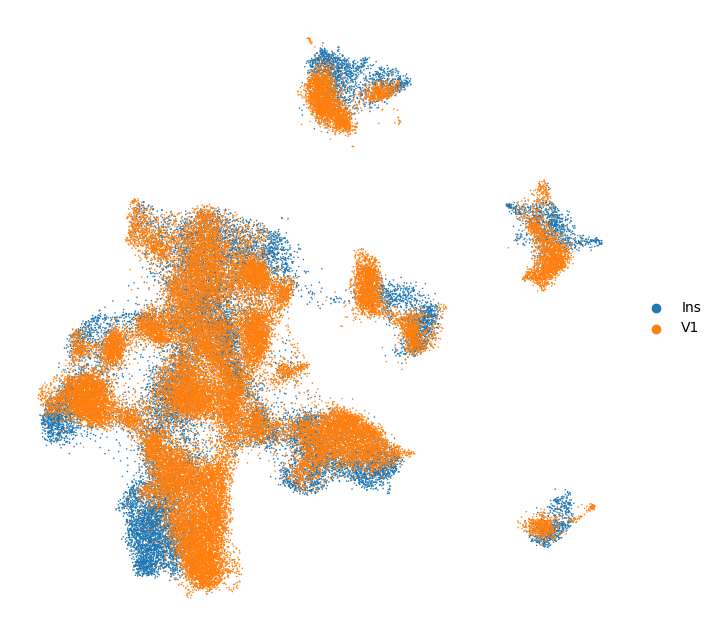

In [35]:
# plot the umaps
figsize(8,8)
sc.pl.umap(adata,color=['brainArea'],legend_loc='right margin',size=5,frameon='',title='',save='clusterCmp_Exc_V1_vs_Ins.pdf')

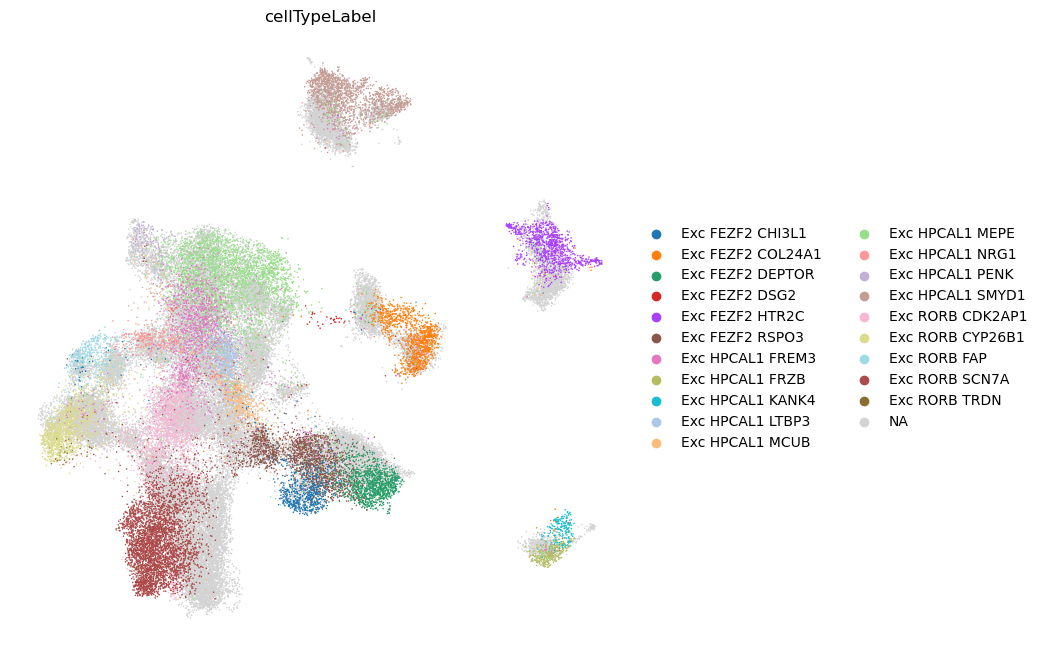

In [61]:
figsize(8,8)
sc.pl.umap(adata,color=['cellTypeLabel'],size=5,frameon='',save='integrateUmapCmp_Exc_V1_vs_Ins_InsVisible.pdf')

/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


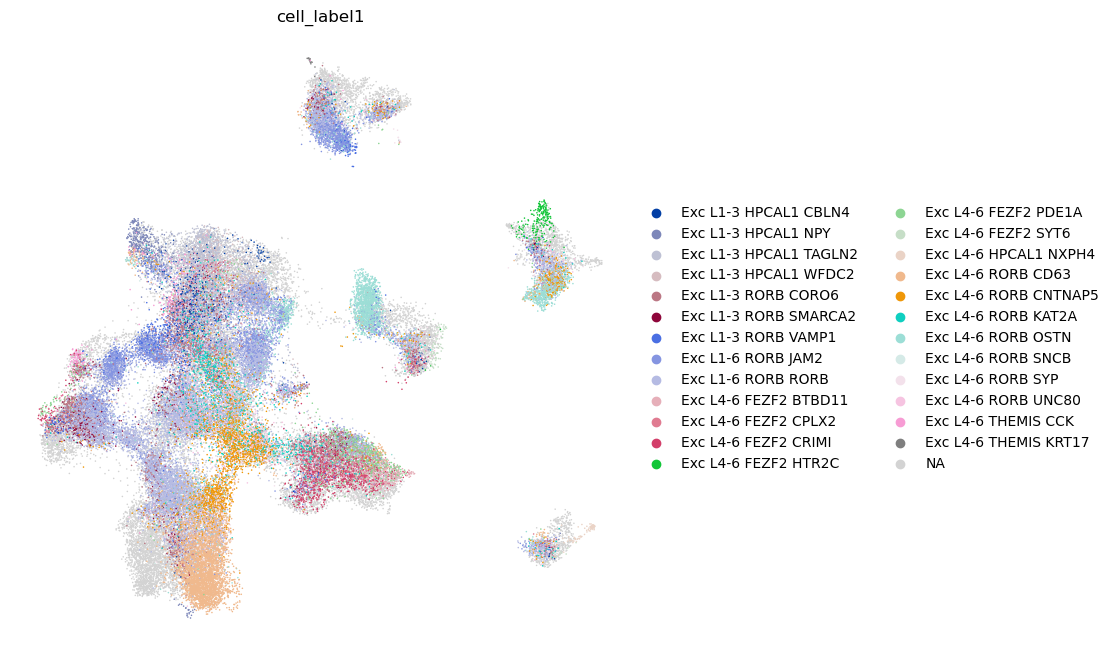

In [37]:
figsize(8,8)
sc.pl.umap(adata,color=['cell_label1'],size=5,frameon='',save='integrateUmapCmp_Exc_V1_vs_Ins_v1Visible.pdf')

In [64]:
adata0

AnnData object with n_obs × n_vars = 69493 × 500
    obs: 'batch', 'doublet_score', 'brainArea', 'species', 'cellTypeID', 'cellTypeLabel', 'pct_counts_mt', 'batch_ori', 'cell_label1', 'subclass_1', 'subclass_2', 'n_genes_by_counts', 'total_counts', 'n_counts', 'louvain', 'tem_leiden'
    var: 'gene_ids-0', 'feature_types-0', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'batch_ori_colors', 'brainArea_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'umap', 'cellTypeID_colors', 'cell_label1_colors', 'louvain', 'species_colors', 'louvain_colors', 'tem_leiden_colors'
    obsm: 'X_pca', 'X_umap', 'X_harmonypca', 'X_umapraw', 'X_umapharmony'
    varm: 'PCs'
    layers: 'RawCounts'
    obsp: 'connectivities', 'distances'

In [38]:
adata0=adata.copy()
adata0.obs['tem_leiden'] = '0'
tem_leiden = adata0.obs['tem_leiden'].astype('str')
tem_leiden[adata0.obs['cellTypeID'].isin(['16'])] = '16'

adata0.obs['tem_leiden'] = tem_leiden.astype('category')

In [67]:
adata0.uns['cell_label1_colors'] 

['#023fa5',
 '#7d87b9',
 '#bec1d4',
 '#d6bcc0',
 '#bb7784',
 '#8e063b',
 '#4a6fe3',
 '#8595e1',
 '#b5bbe3',
 '#e6afb9',
 '#e07b91',
 '#d33f6a',
 '#11c638',
 '#8dd593',
 '#c6dec7',
 '#ead3c6',
 '#f0b98d',
 '#ef9708',
 '#0fcfc0',
 '#9cded6',
 '#d5eae7',
 '#f3e1eb',
 '#f6c4e1',
 '#f79cd4',
 '#7f7f7f']

In [72]:
adata0.uns['tem_leiden_colors']=['#bfbfbf', '#d33f6a']

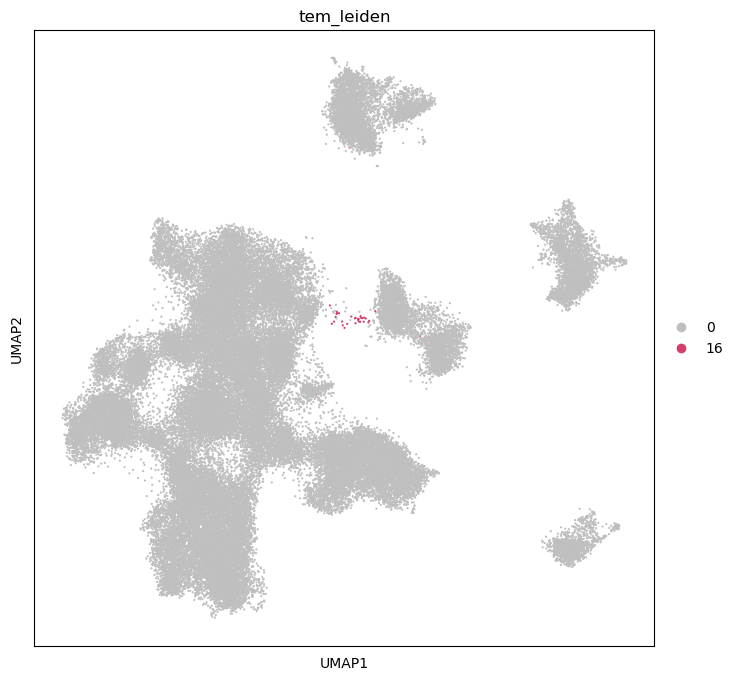

In [73]:
figsize(8,8)
sc.pl.umap(adata0,color=['tem_leiden'],legend_loc='right margin',s=10, save='integrateUMAP_VENcluster.pdf')